<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/ANNs/blob/main/Notebooks/GradCAM.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#####################################################
# Author: Wilfrido Gómez-Flores (Cinvestav)         #
# e-mail: wgomez@cinvestav.mx                       #
# Date:   february 2026                             #
# Subject: Visualize heatmaps by GRAD-CAM           #
#####################################################

# Libraries
import numpy as np                                                    # Numerical array operations
import matplotlib.pyplot as plt                                       # Data plotting/visualization
import tensorflow as tf                                               # Machine learning
from tensorflow.keras.models import Model
import urllib.request                                                 # Open and read URLs
import gdown
import requests # Import the requests library to download files from URLs
from io import BytesIO # To handle image data in memory
from PIL import Image # To handle images
from tensorflow.keras.preprocessing import image
import cv2                                                            # Computer vision

In [ ]:
def read_image(url_drive_link, size=(224, 224)):
    url = 'https://drive.google.com/uc?id=' + url_drive_link.split('/')[-2]
    response = requests.get(url)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    img = img.resize(size)
    img = img.convert('RGB')
    img = image.img_to_array(img) # Convert to numpy array
    img /= 255.0 # Normalize pixels to 0-1 range
    return img

In [ ]:
def load_cnn(url):
  model_name = 'bus_cnn.keras'
  drive_id = url.split('/')[-2]
  download_url = 'https://drive.google.com/uc?export=download&id=' + drive_id
  gdown.download(download_url, model_name, quiet=False)
  model = tf.keras.models.load_model(model_name, compile=False)
  print("Model loaded successfully!")
  return model

In [ ]:
def get_gradcam(model, img_array, last_conv_layer_name):
    img_array = tf.convert_to_tensor(img)
    # 1. Create sub-model
    grad_model = Model([model.inputs[0]],[model.get_layer(last_conv_layer_name).output, model.layers[-1].output])
    # 2. Gradient Tape
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array[np.newaxis, ...])
        target_class = predictions[0]
    # 3. Gradients & Weights
    grads = tape.gradient(target_class, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    # 4. Heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), target_class.numpy()

In [ ]:
def display_gradcam(img, heatmap, alpha=0.4):
    # Resize heatmap
    heatmap = cv2.resize(heatmap, (img.shape[0], img.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    # Convert img to uint8 (0-255) for cv2.addWeighted operation
    img_uint8 = np.uint8(img * 255)
    # Superimpose
    superimposed_img = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_color, alpha, 0)
    # Display
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img) # Display original float img
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img) # Display superimposed uint8 img
    plt.title('Grad-CAM')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Download BUS images
target_size = (224, 224) # CNN input size
opt = 'm'
if opt.lower() == 'b': #  Benign case
    url = 'https://drive.google.com/file/d/1X04MkHBGYnZajOGpsiPJoZprI2GpShIy/view?usp=drive_link'
elif opt.lower() == 'm': # Malignant case
    url = 'https://drive.google.com/file/d/1R21snqtBQLohlj-5oZX_7lZlNuHFcv7D/view?usp=drive_link'
img = read_image(url, size=target_size)

In [ ]:
model = load_cnn('https://drive.google.com/file/d/1lkeJBlPCxvMFF4BQpArvNB6lsoM5g47Y/view?usp=drive_link')
model.summary()

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1lkeJBlPCxvMFF4BQpArvNB6lsoM5g47Y
From (redirected): https://drive.google.com/uc?export=download&id=1lkeJBlPCxvMFF4BQpArvNB6lsoM5g47Y&confirm=t&uuid=b463e11b-4377-45ed-97ac-acaf21801205
To: /content/bus_cnn.keras
100%|██████████| 215M/215M [00:01<00:00, 149MB/s]


Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_2[0][0]     │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 14,978,049 (57.14 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

Predicted class: malignant


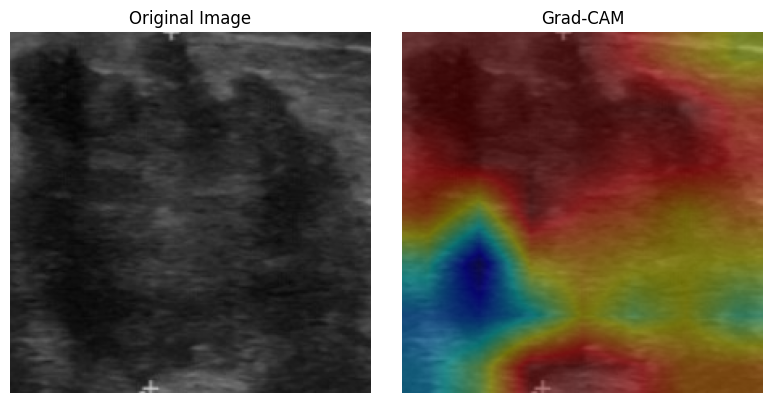

In [ ]:
heatmap, pred = get_gradcam(model, img, last_conv_layer_name="conv5_block3_out")
lbs = ['benign', 'malignant']
print(f'Predicted class: {lbs[(pred>0.5).astype(int)[0]]}')
display_gradcam(img, heatmap, alpha=0.4)